# Re40 PINN analysis

This notebook focuses only on the **Re=40 single-snapshot model**. It removes the earlier Re=60 / multi-Re exploratory cells and keeps the post-training analysis needed to check whether the PINN solution is compatible with the CFD snapshot in terms of **velocity agreement, PDE residual, boundary conditions, and vorticity structure**.


In [1]:
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

os.chdir("/oscar/home/jchen790/cylinder flow lab")

import cfp40
importlib.reload(cfp40)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vtk_path = "/oscar/home/jchen790/cylinder flow lab/Re40.vtk"
save_dir = "checkpoints_re40_single"

snapshot = cfp40.load_single_vtk(vtk_path, t_value=0.0)
model = cfp40.load_model_for_viz(save_dir, device, width=48, depth=3)

print(f"Loaded snapshot with {len(snapshot.x)} points")
print(f"Using device: {device}")


Loaded Re40.vtk  cells=8234
[viz] loaded checkpoints_re40_single/pinn_Re40_single.pt
Loaded snapshot with 8234 points
Using device: cpu


## 1. Velocity agreement with CFD

First check whether the trained PINN reproduces the CFD velocity field at the VTK sample locations. This is the basic data-fit test before looking at stronger physics diagnostics.


In [22]:
def validate_re40_model(vtk_path, save_dir, width=48, depth=3, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    snapshot = cfp40.load_single_vtk(vtk_path, t_value=0.0)
    model = cfp40.load_model_for_viz(save_dir, device, width=width, depth=depth)

    x_np = snapshot.x.astype(np.float32)
    y_np = snapshot.y.astype(np.float32)
    u_true = snapshot.u.astype(np.float32)
    v_true = snapshot.v.astype(np.float32)
    t_np = np.full_like(x_np, 0.0, dtype=np.float32)

    x = torch.tensor(x_np, device=device).view(-1, 1)
    y = torch.tensor(y_np, device=device).view(-1, 1)
    t = torch.tensor(t_np, device=device).view(-1, 1)

    with torch.enable_grad():
        _, u_pred_t, v_pred_t, _ = cfp40.model_uvp(model, x, y, t)

    u_pred = u_pred_t.detach().cpu().numpy().ravel()
    v_pred = v_pred_t.detach().cpu().numpy().ravel()

    speed_true = np.sqrt(u_true**2 + v_true**2)
    speed_pred = np.sqrt(u_pred**2 + v_pred**2)

    err_u = u_pred - u_true
    err_v = v_pred - v_true
    err_speed = speed_pred - speed_true

    metrics = {
        "rmse_u": np.sqrt(np.mean(err_u**2)),
        "rmse_v": np.sqrt(np.mean(err_v**2)),
        "rmse_speed": np.sqrt(np.mean(err_speed**2)),
        "mae_u": np.mean(np.abs(err_u)),
        "mae_v": np.mean(np.abs(err_v)),
        "mae_speed": np.mean(np.abs(err_speed)),
        "rel_l2_u": np.linalg.norm(err_u) / (np.linalg.norm(u_true) + 1e-12),
        "rel_l2_v": np.linalg.norm(err_v) / (np.linalg.norm(v_true) + 1e-12),
        "rel_l2_uv": np.sqrt(np.sum(err_u**2 + err_v**2)) / (np.sqrt(np.sum(u_true**2 + v_true**2)) + 1e-12),
    }

    wake_mask = (x_np >= 0.5) & (x_np <= 12.0) & (np.abs(y_np) <= 3.5)
    metrics["wake_rmse_u"] = np.sqrt(np.mean(err_u[wake_mask]**2))
    metrics["wake_rmse_v"] = np.sqrt(np.mean(err_v[wake_mask]**2))
    metrics["wake_rmse_speed"] = np.sqrt(np.mean(err_speed[wake_mask]**2))

    print("Global metrics:")
    for k, v in metrics.items():
        if not k.startswith("wake_"):
            print(f"{k:>12s} = {v:.6e}")

    print("\nWake-region metrics:")
    print(f"    RMSE u     = {metrics['wake_rmse_u']:.6e}")
    print(f"    RMSE v     = {metrics['wake_rmse_v']:.6e}")
    print(f"    RMSE speed = {metrics['wake_rmse_speed']:.6e}")

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    sc = axes[0, 0].scatter(x_np, y_np, c=u_true, s=6)
    axes[0, 0].set_title("VTK true u")
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("y")
    plt.colorbar(sc, ax=axes[0, 0])

    sc = axes[0, 1].scatter(x_np, y_np, c=u_pred, s=6)
    axes[0, 1].set_title("PINN pred u")
    axes[0, 1].set_xlabel("x")
    axes[0, 1].set_ylabel("y")
    plt.colorbar(sc, ax=axes[0, 1])

    sc = axes[0, 2].scatter(x_np, y_np, c=err_u, s=6, cmap="coolwarm")
    axes[0, 2].set_title("u error = pred - true")
    axes[0, 2].set_xlabel("x")
    axes[0, 2].set_ylabel("y")
    plt.colorbar(sc, ax=axes[0, 2])

    sc = axes[1, 0].scatter(x_np, y_np, c=v_true, s=6)
    axes[1, 0].set_title("VTK true v")
    axes[1, 0].set_xlabel("x")
    axes[1, 0].set_ylabel("y")
    plt.colorbar(sc, ax=axes[1, 0])

    sc = axes[1, 1].scatter(x_np, y_np, c=v_pred, s=6)
    axes[1, 1].set_title("PINN pred v")
    axes[1, 1].set_xlabel("x")
    axes[1, 1].set_ylabel("y")
    plt.colorbar(sc, ax=axes[1, 1])

    sc = axes[1, 2].scatter(x_np, y_np, c=err_v, s=6, cmap="coolwarm")
    axes[1, 2].set_title("v error = pred - true")
    axes[1, 2].set_xlabel("x")
    axes[1, 2].set_ylabel("y")
    plt.colorbar(sc, ax=axes[1, 2])

    plt.tight_layout()
    plt.show()

    return metrics, {
        "snapshot": snapshot,
        "u_true": u_true,
        "v_true": v_true,
        "u_pred": u_pred,
        "v_pred": v_pred,
        "err_u": err_u,
        "err_v": err_v,
        "x": x_np,
        "y": y_np,
    }


Loaded Re40.vtk  cells=8234
[viz] loaded checkpoints_re40_single/pinn_Re40_single.pt
Global metrics:
      rmse_u = 1.431744e-01
      rmse_v = 8.957968e-02
  rmse_speed = 1.620911e-01
       mae_u = 6.257459e-02
       mae_v = 4.007770e-02
   mae_speed = 6.947839e-02
    rel_l2_u = 1.586190e-01
    rel_l2_v = 9.121942e-01
   rel_l2_uv = 1.860097e-01

Wake-region metrics:
    RMSE u     = 3.491209e-02
    RMSE v     = 2.239267e-02
    RMSE speed = 3.487730e-02


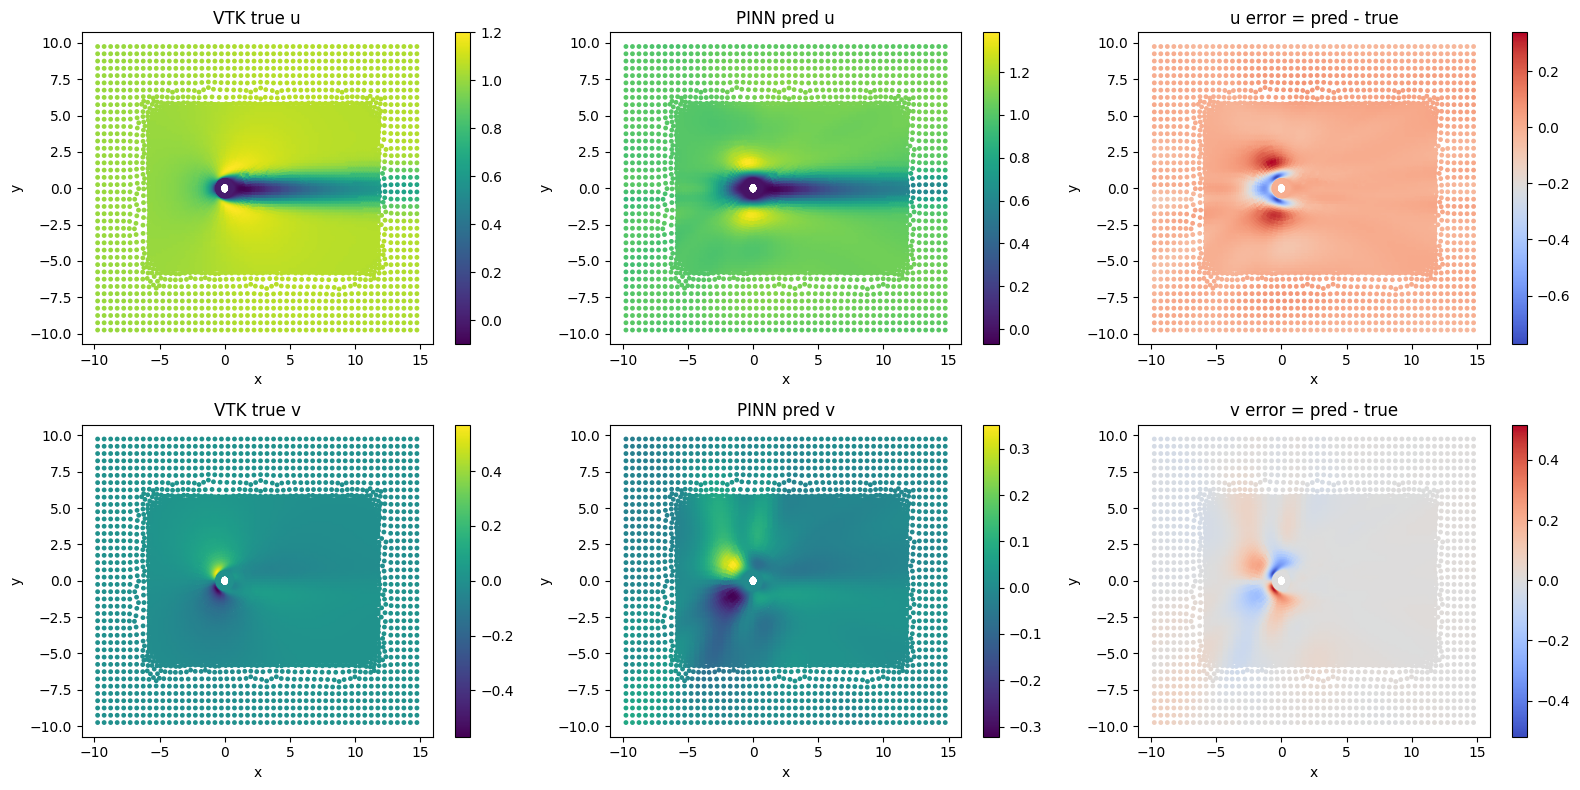

In [23]:
vel_metrics, vel_data = validate_re40_model(
    vtk_path=vtk_path,
    save_dir=save_dir,
    width=48,
    depth=3,
    device=device,
)


## 2. PDE residual diagnostics

These checks ask whether the trained field is not only close to CFD pointwise, but also close to satisfying the same Navier–Stokes equations used in training. The most useful question is whether the residual is small everywhere or mostly concentrated near the cylinder.


In [24]:
def compute_pde_residual_fields(model, x, y, t, Re=40.0):
    _, u, v, p = cfp40.model_uvp(model, x, y, t)

    u_t = cfp40.grad(u, t)
    v_t = cfp40.grad(v, t)
    u_x = cfp40.grad(u, x)
    v_x = cfp40.grad(v, x)
    u_y = cfp40.grad(u, y)
    v_y = cfp40.grad(v, y)
    p_x = cfp40.grad(p, x)
    p_y = cfp40.grad(p, y)
    u_xx = cfp40.grad(u_x, x)
    u_yy = cfp40.grad(u_y, y)
    v_xx = cfp40.grad(v_x, x)
    v_yy = cfp40.grad(v_y, y)

    nu = 1.0 / Re
    f_u = u_t + u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
    f_v = v_t + u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)
    return f_u, f_v


def sample_collocation_numpy(n_f=20000,
                             xlim=(-5.0, 25.0),
                             ylim=(-10.0, 10.0),
                             radius=0.5):
    n1 = int(0.5 * n_f)
    n2 = int(0.3 * n_f)
    n3 = n_f - n1 - n2

    x1 = np.random.uniform(xlim[0], xlim[1], size=n1)
    y1 = np.random.uniform(ylim[0], ylim[1], size=n1)
    x2 = np.random.uniform(0.0, 12.0, size=n2)
    y2 = np.random.uniform(-3.0, 3.0, size=n2)
    theta = np.random.uniform(0.0, 2*np.pi, size=n3)
    rr = np.random.uniform(radius + 0.02, radius + 0.35, size=n3)
    x3 = rr * np.cos(theta)
    y3 = rr * np.sin(theta)

    x = np.concatenate([x1, x2, x3])
    y = np.concatenate([y1, y2, y3])
    mask = (x**2 + y**2) >= radius**2
    return x[mask], y[mask]


def pde_residual_diagnostics(model, device, Re=40.0, n_f=20000):
    xx, yy = sample_collocation_numpy(n_f=n_f)
    x = torch.tensor(xx, dtype=torch.float32, device=device).view(-1, 1)
    y = torch.tensor(yy, dtype=torch.float32, device=device).view(-1, 1)
    t = torch.zeros_like(x)

    f_u, f_v = compute_pde_residual_fields(model, x, y, t, Re=Re)
    fu = f_u.detach().cpu().numpy().reshape(-1)
    fv = f_v.detach().cpu().numpy().reshape(-1)
    mag = np.sqrt(fu**2 + fv**2)

    wake_mask = (xx >= 0.5) & (xx <= 12.0) & (np.abs(yy) <= 3.5)
    near_cyl_mask = ((xx**2 + yy**2) >= (0.52)**2) & ((xx**2 + yy**2) <= (0.85)**2)

    metrics = {
        "pde_rmse_mag": np.sqrt(np.mean(fu**2 + fv**2)),
        "pde_mae_mag": np.mean(mag),
        "pde_p95_mag": np.percentile(mag, 95),
        "pde_p99_mag": np.percentile(mag, 99),
        "wake_pde_rmse_mag": np.sqrt(np.mean(fu[wake_mask]**2 + fv[wake_mask]**2)),
        "near_cyl_pde_rmse_mag": np.sqrt(np.mean(fu[near_cyl_mask]**2 + fv[near_cyl_mask]**2)),
    }
    detail = {"x": xx, "y": yy, "fu": fu, "fv": fv, "mag": mag}
    return metrics, detail


In [25]:
pde_metrics, pde_detail = pde_residual_diagnostics(model, device, Re=40.0, n_f=20000)

print("=== PDE residual diagnostics ===")
for k, v in pde_metrics.items():
    print(f"{k:>24s} = {v:.6e}")


=== PDE residual diagnostics ===
            pde_rmse_mag = 6.100095e-02
             pde_mae_mag = 3.423335e-02
             pde_p95_mag = 1.236485e-01
             pde_p99_mag = 2.889573e-01
       wake_pde_rmse_mag = 2.544910e-02
   near_cyl_pde_rmse_mag = 1.253490e-01


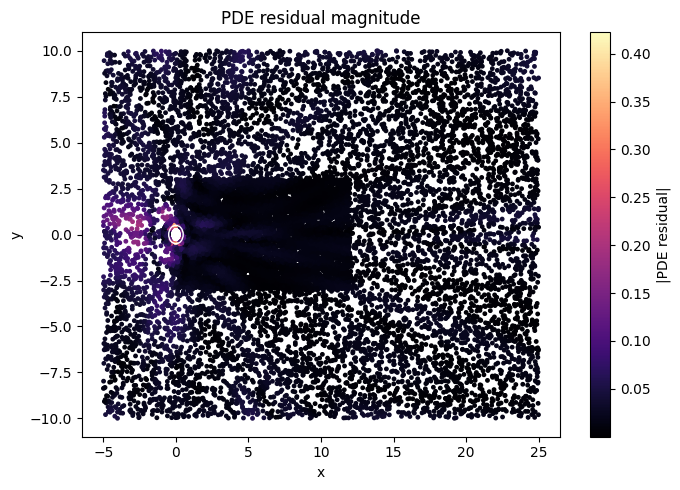

In [26]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(pde_detail["x"], pde_detail["y"], c=pde_detail["mag"], s=6, cmap="magma")
plt.colorbar(sc, label="|PDE residual|")
plt.gca().add_patch(plt.Circle((0.0, 0.0), 0.5, color="w", fill=False))
plt.xlabel("x")
plt.ylabel("y")
plt.title("PDE residual magnitude")
plt.tight_layout()
plt.show()


## 3. Boundary-condition diagnostics

These checks separate the boundary loss into inlet, top/bottom, cylinder wall, and outlet pieces. The cylinder wall is the most important part for judging near-wall compatibility with CFD.


In [27]:
def boundary_diagnostics(model, device, n=2000):
    yi = torch.linspace(-10.0, 10.0, n, device=device).view(-1, 1)
    xi = torch.full_like(yi, -5.0)
    ti = torch.zeros_like(yi)
    _, u_i, v_i, _ = cfp40.model_uvp(model, xi, yi, ti)

    xt = torch.linspace(-5.0, 25.0, n, device=device).view(-1, 1)
    yt = torch.full_like(xt, 10.0)
    tt = torch.zeros_like(xt)
    _, u_t, v_t, _ = cfp40.model_uvp(model, xt, yt, tt)

    xb = torch.linspace(-5.0, 25.0, n, device=device).view(-1, 1)
    yb = torch.full_like(xb, -10.0)
    tb = torch.zeros_like(xb)
    _, u_b, v_b, _ = cfp40.model_uvp(model, xb, yb, tb)

    theta = torch.linspace(-np.pi, np.pi, n, device=device).view(-1, 1)
    xw = 0.5 * torch.cos(theta)
    yw = 0.5 * torch.sin(theta)
    tw = torch.zeros_like(xw)
    _, u_w, v_w, _ = cfp40.model_uvp(model, xw, yw, tw)

    yo = torch.linspace(-10.0, 10.0, n, device=device).view(-1, 1)
    xo = torch.full_like(yo, 25.0)
    to = torch.zeros_like(yo)
    _, u_o, v_o, p_o = cfp40.model_uvp(model, xo, yo, to)
    u_x_o = cfp40.grad(u_o, xo)
    v_x_o = cfp40.grad(v_o, xo)

    wall_speed = torch.sqrt(u_w**2 + v_w**2)

    metrics = {
        "inlet_u_rmse_to_1": torch.sqrt(torch.mean((u_i - 1.0)**2)).item(),
        "inlet_v_rmse_to_0": torch.sqrt(torch.mean(v_i**2)).item(),
        "top_u_rmse_to_1": torch.sqrt(torch.mean((u_t - 1.0)**2)).item(),
        "top_v_rmse_to_0": torch.sqrt(torch.mean(v_t**2)).item(),
        "bottom_u_rmse_to_1": torch.sqrt(torch.mean((u_b - 1.0)**2)).item(),
        "bottom_v_rmse_to_0": torch.sqrt(torch.mean(v_b**2)).item(),
        "wall_u_rmse_to_0": torch.sqrt(torch.mean(u_w**2)).item(),
        "wall_v_rmse_to_0": torch.sqrt(torch.mean(v_w**2)).item(),
        "wall_speed_mean": torch.mean(wall_speed).item(),
        "wall_speed_p95": torch.quantile(wall_speed.reshape(-1), 0.95).item(),
        "outlet_p_rmse_to_0": torch.sqrt(torch.mean(p_o**2)).item(),
        "outlet_ux_rmse_to_0": torch.sqrt(torch.mean(u_x_o**2)).item(),
        "outlet_vx_rmse_to_0": torch.sqrt(torch.mean(v_x_o**2)).item(),
    }

    detail = {
        "theta": theta.detach().cpu().numpy().reshape(-1),
        "u_wall": u_w.detach().cpu().numpy().reshape(-1),
        "v_wall": v_w.detach().cpu().numpy().reshape(-1),
        "wall_speed": wall_speed.detach().cpu().numpy().reshape(-1),
    }
    return metrics, detail


In [28]:
bc_metrics, bc_detail = boundary_diagnostics(model, device, n=2000)

print("=== Boundary diagnostics ===")
for k, v in bc_metrics.items():
    print(f"{k:>24s} = {v:.6e}")


=== Boundary diagnostics ===
       inlet_u_rmse_to_1 = 1.209361e-02
       inlet_v_rmse_to_0 = 9.579043e-03
         top_u_rmse_to_1 = 5.798906e-03
         top_v_rmse_to_0 = 7.065990e-03
      bottom_u_rmse_to_1 = 6.764814e-03
      bottom_v_rmse_to_0 = 6.067415e-03
        wall_u_rmse_to_0 = 2.542976e-09
        wall_v_rmse_to_0 = 1.206014e-09
         wall_speed_mean = 9.492773e-10
          wall_speed_p95 = 8.732004e-09
      outlet_p_rmse_to_0 = 6.360884e-03
     outlet_ux_rmse_to_0 = 4.923878e-03
     outlet_vx_rmse_to_0 = 2.331323e-03


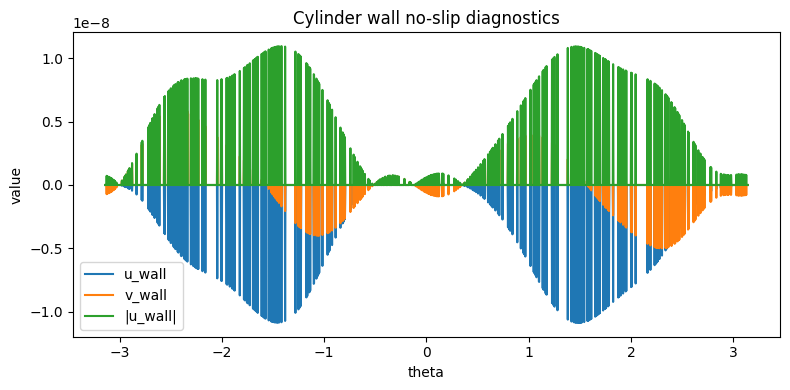

In [29]:
order = np.argsort(bc_detail["theta"])
plt.figure(figsize=(8, 4))
plt.plot(bc_detail["theta"][order], bc_detail["u_wall"][order], label="u_wall")
plt.plot(bc_detail["theta"][order], bc_detail["v_wall"][order], label="v_wall")
plt.plot(bc_detail["theta"][order], bc_detail["wall_speed"][order], label="|u_wall|")
plt.xlabel("theta")
plt.ylabel("value")
plt.title("Cylinder wall no-slip diagnostics")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Vorticity compatibility

Velocity agreement can still look good even when derivative-based quantities are wrong. Vorticity is a stricter test because it depends on spatial derivatives and is sensitive to near-wall shear and separation structure.


In [30]:
def finite_difference_vorticity(snapshot, nx=260, ny=140,
                                xlim=(-2.0, 10.0), ylim=(-3.0, 3.0)):
    xs = np.linspace(xlim[0], xlim[1], nx, dtype=np.float32)
    ys = np.linspace(ylim[0], ylim[1], ny, dtype=np.float32)
    X, Y = np.meshgrid(xs, ys)

    U = np.full((ny, nx), np.nan, dtype=np.float32)
    V = np.full((ny, nx), np.nan, dtype=np.float32)
    C = np.zeros((ny, nx), dtype=np.int32)

    ix = np.clip(np.round((snapshot.x - xlim[0]) / (xlim[1] - xlim[0]) * (nx - 1)).astype(int), 0, nx - 1)
    iy = np.clip(np.round((snapshot.y - ylim[0]) / (ylim[1] - ylim[0]) * (ny - 1)).astype(int), 0, ny - 1)

    acc_u = np.zeros((ny, nx), dtype=np.float64)
    acc_v = np.zeros((ny, nx), dtype=np.float64)
    for j, i, uu, vv in zip(iy, ix, snapshot.u, snapshot.v):
        acc_u[j, i] += float(uu)
        acc_v[j, i] += float(vv)
        C[j, i] += 1

    mask = C > 0
    U[mask] = (acc_u[mask] / C[mask]).astype(np.float32)
    V[mask] = (acc_v[mask] / C[mask]).astype(np.float32)

    for arr in [U, V]:
        for j in range(ny):
            valid = np.where(~np.isnan(arr[j]))[0]
            if len(valid) > 0:
                arr[j] = np.interp(np.arange(nx), valid, arr[j, valid])
        for i in range(nx):
            valid = np.where(~np.isnan(arr[:, i]))[0]
            if len(valid) > 0:
                arr[:, i] = np.interp(np.arange(ny), valid, arr[valid, i])

    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]
    dVdx = np.gradient(V, dx, axis=1)
    dUdy = np.gradient(U, dy, axis=0)
    W = dVdx - dUdy

    cyl_mask = (X**2 + Y**2) <= 0.5**2
    W[cyl_mask] = np.nan
    return X, Y, W


def pinn_vorticity_on_grid(model, device, nx=260, ny=140,
                           xlim=(-2.0, 10.0), ylim=(-3.0, 3.0)):
    xs = np.linspace(xlim[0], xlim[1], nx, dtype=np.float32)
    ys = np.linspace(ylim[0], ylim[1], ny, dtype=np.float32)
    X, Y = np.meshgrid(xs, ys)

    x = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=device)
    y = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32, device=device)
    t = torch.zeros_like(x)

    W = cfp40.model_vorticity(model, x, y, t).detach().cpu().numpy().reshape(ny, nx)
    cyl_mask = (X**2 + Y**2) <= 0.5**2
    W[cyl_mask] = np.nan
    return X, Y, W


def vorticity_metrics(W_true, W_pred):
    valid = ~np.isnan(W_true) & ~np.isnan(W_pred)
    diff = W_pred - W_true
    return {
        "omega_rmse": np.sqrt(np.mean(diff[valid]**2)),
        "omega_mae": np.mean(np.abs(diff[valid])),
        "omega_rel_l2": np.linalg.norm(diff[valid]) / (np.linalg.norm(W_true[valid]) + 1e-12),
        "omega_corr": np.corrcoef(W_true[valid].reshape(-1), W_pred[valid].reshape(-1))[0, 1],
    }, diff


In [31]:
X, Y, W_cfd = finite_difference_vorticity(snapshot)
_, _, W_pinn = pinn_vorticity_on_grid(model, device)
omega_metrics, W_diff = vorticity_metrics(W_cfd, W_pinn)

print("=== Vorticity comparison ===")
for k, v in omega_metrics.items():
    print(f"{k:>20s} = {v:.6e}")


=== Vorticity comparison ===
          omega_rmse = 1.274641e+00
           omega_mae = 6.618887e-01
        omega_rel_l2 = 9.419918e-01
          omega_corr = 3.392515e-01


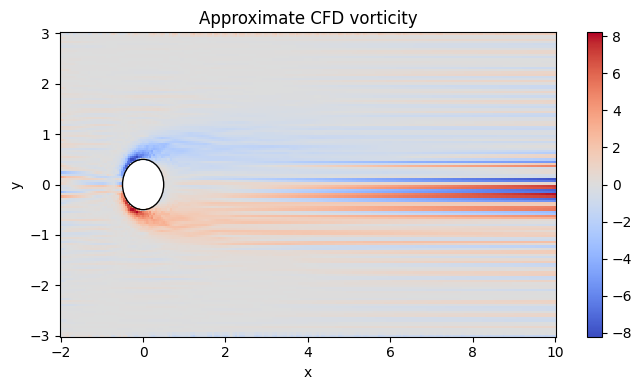

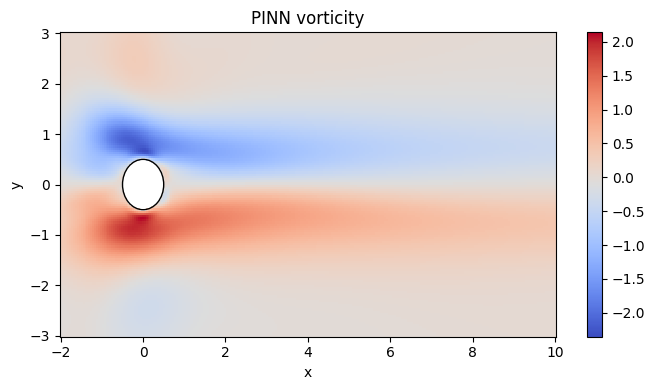

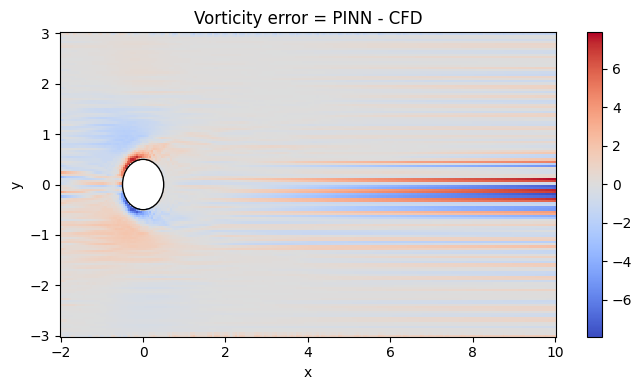

In [32]:
for field, title in [
    (W_cfd, "Approximate CFD vorticity"),
    (W_pinn, "PINN vorticity"),
    (W_diff, "Vorticity error = PINN - CFD"),
]:
    plt.figure(figsize=(7, 4))
    plt.pcolormesh(X, Y, field, shading="auto", cmap="coolwarm")
    plt.colorbar()
    plt.gca().add_patch(plt.Circle((0.0, 0.0), 0.5, color="k", fill=False))
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 5. Compatibility summary

This final cell gives a short interpretation of the four checks: velocity fit, PDE residual, wall boundary condition, and vorticity structure.


In [33]:
print("=== Compatibility summary ===")

if vel_metrics["rel_l2_uv"] < 0.10:
    print("- Velocity field is globally close to CFD.")
else:
    print("- Velocity field still has noticeable mismatch.")

if pde_metrics["near_cyl_pde_rmse_mag"] > 1.5 * pde_metrics["pde_rmse_mag"]:
    print("- PDE residual is concentrated near the cylinder.")
else:
    print("- PDE residual is not only a near-cylinder issue.")

if bc_metrics["wall_speed_p95"] < 0.05:
    print("- Wall no-slip condition is strongly enforced.")
elif bc_metrics["wall_speed_p95"] < 0.10:
    print("- Wall no-slip is moderately enforced but not perfect.")
else:
    print("- Wall no-slip is still weak.")

if omega_metrics["omega_rel_l2"] < 0.25 and omega_metrics["omega_corr"] > 0.8:
    print("- Vorticity structure is fairly compatible with CFD.")
elif omega_metrics["omega_rel_l2"] < 0.50 and omega_metrics["omega_corr"] > 0.5:
    print("- Vorticity captures the main trend but misses fine near-wall detail.")
else:
    print("- Vorticity mismatch is still significant.")


=== Compatibility summary ===
- Velocity field still has noticeable mismatch.
- PDE residual is concentrated near the cylinder.
- Wall no-slip condition is strongly enforced.
- Vorticity mismatch is still significant.


In [34]:
import pyvista as pv
import numpy as np

mesh = pv.read("Re40.vtk")

# 优先用 point data
if "U" in mesh.point_data:
    src = mesh.copy()
    assoc = "point"
    vec_name = "U"
elif "U" in mesh.cell_data:
    src = mesh.cell_data_to_point_data()
    assoc = "cell->point"
    vec_name = "U"
else:
    raise KeyError("Could not find velocity field 'U' in VTK.")

print("using:", assoc, vec_name)
print(src)

using: point U
UnstructuredGrid (0x7fec80512bc0)
  N Cells:    8234
  N Points:   16360
  X Bounds:   -1.000e+01, 1.500e+01
  Y Bounds:   -1.000e+01, 1.000e+01
  Z Bounds:   0.000e+00, 1.000e+00
  N Arrays:   13


In [35]:
# Compute derivatives of velocity field
# gradient tensor of U will be stored in "gradient"
deriv = src.compute_derivative(scalars=vec_name, gradient=True, vorticity=True)

print("new point_data:", list(deriv.point_data.keys()))
print("new cell_data:", list(deriv.cell_data.keys()))

new point_data: ['pMean', 'p', 'pPrime2Mean', 'UMean', 'U', 'UPrime2Mean', 'gradient', 'vorticity']
new cell_data: ['cellID', 'pMean', 'p', 'pPrime2Mean', 'UMean', 'U', 'UPrime2Mean']


In [36]:
if "vorticity" in deriv.point_data:
    vort = np.asarray(deriv.point_data["vorticity"])
elif "vorticity" in deriv.cell_data:
    vort = np.asarray(deriv.cell_data["vorticity"])
else:
    raise KeyError("No vorticity array produced by compute_derivative.")

print("vorticity shape:", vort.shape)
print("first few rows:\n", vort[:5])

omega_cfd = vort[:, 2]
print("omega_cfd min/max:", omega_cfd.min(), omega_cfd.max())

vorticity shape: (16360, 3)
first few rows:
 [[-7.4989407e-21 -5.8922422e-21  2.9956312e-03]
 [ 1.5280343e-20  2.7673159e-20  2.9145507e-03]
 [-4.5959322e-21  8.5299592e-21  2.9009518e-03]
 [-2.9258286e-20 -1.3898857e-20  2.8698535e-03]
 [-1.7197343e-20  3.0883705e-21  2.9010060e-03]]
omega_cfd min/max: -12.167919 12.167794


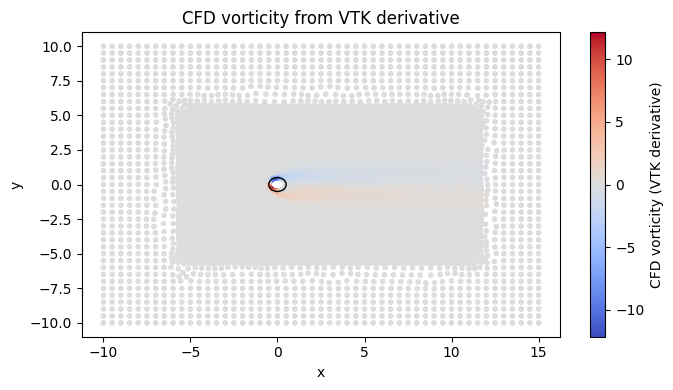

In [37]:
import matplotlib.pyplot as plt

pts = deriv.points
x = pts[:, 0]
y = pts[:, 1]

plt.figure(figsize=(7, 4))
sc = plt.scatter(x, y, c=omega_cfd, s=8, cmap="coolwarm")
plt.colorbar(sc, label="CFD vorticity (VTK derivative)")
plt.gca().add_patch(plt.Circle((0.0, 0.0), 0.5, color="k", fill=False))
plt.xlabel("x")
plt.ylabel("y")
plt.title("CFD vorticity from VTK derivative")
plt.tight_layout()
plt.show()

In [38]:
import torch

def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

def model_vorticity(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    out = model(torch.cat([x, y, t], dim=1))
    psi = out[:, 0:1]

    u = grad(psi, y)
    v = -grad(psi, x)

    u_y = grad(u, y)
    v_x = grad(v, x)

    return v_x - u_y

In [39]:
import torch

# CFD sample points
x_t = torch.tensor(x, dtype=torch.float32, device=device).view(-1, 1)
y_t = torch.tensor(y, dtype=torch.float32, device=device).view(-1, 1)
t_t = torch.zeros_like(x_t)

omega_pinn = model_vorticity(model, x_t, y_t, t_t).detach().cpu().numpy().reshape(-1)

# exclude points inside cylinder
mask = (x**2 + y**2) >= 0.5**2

err = omega_pinn[mask] - omega_cfd[mask]

print("omega_rmse =", np.sqrt(np.mean(err**2)))
print("omega_mae  =", np.mean(np.abs(err)))
print("omega_rel_l2 =", np.linalg.norm(err) / (np.linalg.norm(omega_cfd[mask]) + 1e-12))
print("omega_corr =", np.corrcoef(omega_pinn[mask], omega_cfd[mask])[0, 1])

omega_rmse = 2.1721964
omega_mae  = 0.73002666
omega_rel_l2 = 0.9324916137266536
omega_corr = 0.4194003880108922


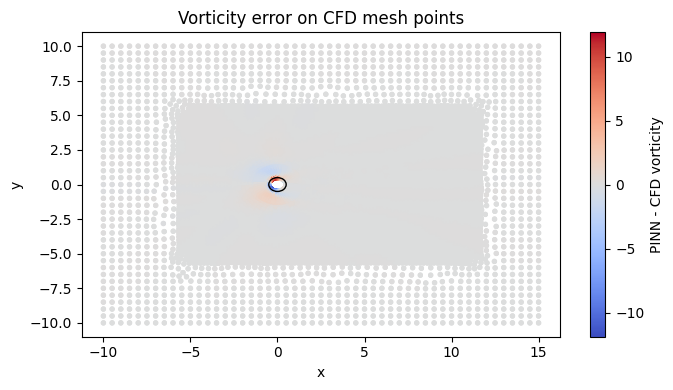

In [40]:
plt.figure(figsize=(7, 4))
sc = plt.scatter(x[mask], y[mask], c=err, s=8, cmap="coolwarm")
plt.colorbar(sc, label="PINN - CFD vorticity")
plt.gca().add_patch(plt.Circle((0.0, 0.0), 0.5, color="k", fill=False))
plt.xlabel("x")
plt.ylabel("y")
plt.title("Vorticity error on CFD mesh points")
plt.tight_layout()
plt.show()